<a href="https://colab.research.google.com/github/iremcesur/CENG467_Midterm_310201051/blob/main/q1_tfidf_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from getpass import getpass

github_token = getpass('GitHub token: ')
github_user = 'iremcesur'
repo_name = 'CENG467_Midterm_310201051'

!git clone https://{github_token}@github.com/{github_user}/{repo_name}.git
%cd {repo_name}

!git config user.email "iremcesur310201051@gmail.com"
!git config user.name "iremcesur"

GitHub token: ··········
Cloning into 'CENG467_Midterm_310201051'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 3), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 8.14 KiB | 2.03 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/CENG467_Midterm_310201051


In [2]:
# Reproducibility setup
import random
import numpy as np
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"✓ Random seed set to {SEED}")

✓ Random seed set to 42


In [3]:
!pip install -q datasets
print("✓ Libraries installed")

✓ Libraries installed


In [4]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time

print("✓ All imports successful")

✓ All imports successful


In [5]:
# Load IMDB dataset from Huggingface
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

print(f"\nDataset structure:")
print(dataset)
print(f"\nTrain size: {len(dataset['train'])}")
print(f"Test size: {len(dataset['test'])}")
print(f"\nSample example:")
print(f"Label: {dataset['train'][0]['label']}")
print(f"Text (first 300 chars): {dataset['train'][0]['text'][:300]}...")

Loading IMDb dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size: 25000
Test size: 25000

Sample example:
Label: 0
Text (first 300 chars): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


In [6]:
# Train ve test'i pandas DataFrame'e çevir
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Original train: {len(train_df)} | test: {len(test_df)}")
print(f"Train label distribution: {train_df['label'].value_counts().to_dict()}")
print(f"Test label distribution: {test_df['label'].value_counts().to_dict()}")

Original train: 25000 | test: 25000
Train label distribution: {0: 12500, 1: 12500}
Test label distribution: {0: 12500, 1: 12500}


In [7]:
# Stratified subset: train 5000, val 1000 (train'den ayır), test 2000

# Train'den 6000 al → 5000 train + 1000 val
train_subset, val_subset = train_test_split(
    train_df.sample(n=6000, random_state=SEED, replace=False),
    test_size=1000,
    stratify=train_df.sample(n=6000, random_state=SEED, replace=False)['label'],
    random_state=SEED
)

# Test'ten 2000 al
test_subset = test_df.sample(n=2000, random_state=SEED, replace=False)

# Index'leri sıfırla
train_subset = train_subset.reset_index(drop=True)
val_subset = val_subset.reset_index(drop=True)
test_subset = test_subset.reset_index(drop=True)

print(f"\nSubset sizes:")
print(f"  Train: {len(train_subset)} | Label dist: {train_subset['label'].value_counts().to_dict()}")
print(f"  Val:   {len(val_subset)}  | Label dist: {val_subset['label'].value_counts().to_dict()}")
print(f"  Test:  {len(test_subset)} | Label dist: {test_subset['label'].value_counts().to_dict()}")


Subset sizes:
  Train: 5000 | Label dist: {1: 2507, 0: 2493}
  Val:   1000  | Label dist: {1: 501, 0: 499}
  Test:  2000 | Label dist: {0: 1040, 1: 960}


In [8]:
import os
os.makedirs('data/processed', exist_ok=True)

train_subset.to_csv('data/processed/imdb_train.csv', index=False)
val_subset.to_csv('data/processed/imdb_val.csv', index=False)
test_subset.to_csv('data/processed/imdb_test.csv', index=False)

print("✓ Subsets saved to data/processed/")
!ls -la data/processed/

✓ Subsets saved to data/processed/
total 10396
drwxr-xr-x 2 root root    4096 May  5 19:05 .
drwxr-xr-x 3 root root    4096 May  5 19:05 ..
-rw-r--r-- 1 root root 2574379 May  5 19:05 imdb_test.csv
-rw-r--r-- 1 root root 6683324 May  5 19:05 imdb_train.csv
-rw-r--r-- 1 root root 1374857 May  5 19:05 imdb_val.csv


In [9]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

english_stopwords = stopwords.words('english')
print(f"✓ NLTK stopwords loaded: {len(english_stopwords)} words")
print(f"Sample: {english_stopwords[:10]}")

✓ NLTK stopwords loaded: 198 words
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [10]:
def train_tfidf_logreg(
    train_texts, train_labels,
    val_texts, val_labels,
    config_name,
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 1),
    max_features=20000
):
    """
    TF-IDF + Logistic Regression eğit ve validation accuracy döndür.
    Tüm konfigürasyonlar için aynı sınıflandırıcı, sadece preprocessing değişiyor.
    """
    print(f"\n{'='*60}")
    print(f"Config: {config_name}")
    print(f"  lowercase={lowercase}, stop_words={'yes' if stop_words else 'no'}, "
          f"ngram={ngram_range}, max_features={max_features}")
    print(f"{'='*60}")

    start = time.time()

    # TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        lowercase=lowercase,
        stop_words=stop_words,
        ngram_range=ngram_range,
        max_features=max_features,
        sublinear_tf=True  # Log scaling — uzun dökümanlar için iyi
    )

    X_train = vectorizer.fit_transform(train_texts)
    X_val = vectorizer.transform(val_texts)

    print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"  Train shape: {X_train.shape}")

    # Logistic Regression
    clf = LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        C=1.0,  # Default regularization
        solver='liblinear'  # Sparse data için iyi
    )
    clf.fit(X_train, train_labels)

    # Validation evaluation
    val_preds = clf.predict(X_val)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    elapsed = time.time() - start

    print(f"  Val Accuracy: {val_acc:.4f}")
    print(f"  Val Macro-F1: {val_f1:.4f}")
    print(f"  Time: {elapsed:.1f}s")

    return {
        'config': config_name,
        'vectorizer': vectorizer,
        'clf': clf,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'time': elapsed
    }

print("✓ Helper function defined")

✓ Helper function defined


In [11]:
# Train ve val verisi hazırla
train_texts = train_subset['text'].tolist()
train_labels = train_subset['label'].tolist()
val_texts = val_subset['text'].tolist()
val_labels = val_subset['label'].tolist()

# 4 konfigürasyon
configs = []

# Config 1: Baseline — sadece unigram, lowercase
configs.append(train_tfidf_logreg(
    train_texts, train_labels, val_texts, val_labels,
    config_name="1. Baseline (unigram, lowercase)",
    lowercase=True, stop_words=None, ngram_range=(1, 1)
))

# Config 2: + Stopword removal
configs.append(train_tfidf_logreg(
    train_texts, train_labels, val_texts, val_labels,
    config_name="2. + Stopword removal",
    lowercase=True, stop_words=english_stopwords, ngram_range=(1, 1)
))

# Config 3: + Bigrams (1-2)
configs.append(train_tfidf_logreg(
    train_texts, train_labels, val_texts, val_labels,
    config_name="3. + Bigrams (uni+bi)",
    lowercase=True, stop_words=None, ngram_range=(1, 2)
))

# Config 4: Tüm geliştirmeler (bigram + stopword removal)
configs.append(train_tfidf_logreg(
    train_texts, train_labels, val_texts, val_labels,
    config_name="4. Bigrams + Stopword removal",
    lowercase=True, stop_words=english_stopwords, ngram_range=(1, 2)
))

print("\n✓ All configurations trained")


Config: 1. Baseline (unigram, lowercase)
  lowercase=True, stop_words=no, ngram=(1, 1), max_features=20000
  Vocabulary size: 20000
  Train shape: (5000, 20000)
  Val Accuracy: 0.8570
  Val Macro-F1: 0.8570
  Time: 5.9s

Config: 2. + Stopword removal
  lowercase=True, stop_words=yes, ngram=(1, 1), max_features=20000
  Vocabulary size: 20000
  Train shape: (5000, 20000)
  Val Accuracy: 0.8560
  Val Macro-F1: 0.8559
  Time: 3.2s

Config: 3. + Bigrams (uni+bi)
  lowercase=True, stop_words=no, ngram=(1, 2), max_features=20000
  Vocabulary size: 20000
  Train shape: (5000, 20000)
  Val Accuracy: 0.8640
  Val Macro-F1: 0.8640
  Time: 12.1s

Config: 4. Bigrams + Stopword removal
  lowercase=True, stop_words=yes, ngram=(1, 2), max_features=20000
  Vocabulary size: 20000
  Train shape: (5000, 20000)
  Val Accuracy: 0.8690
  Val Macro-F1: 0.8689
  Time: 9.6s

✓ All configurations trained


In [12]:
# Ablation tablosu
ablation_df = pd.DataFrame([
    {
        'Configuration': c['config'],
        'Val Accuracy': c['val_acc'],
        'Val Macro-F1': c['val_f1'],
        'Time (s)': c['time']
    }
    for c in configs
])

print("=" * 70)
print("TF-IDF ABLATION RESULTS (Validation Set)")
print("=" * 70)
print(ablation_df.to_string(index=False))

# En iyi konfigürasyonu bul
best_idx = ablation_df['Val Macro-F1'].idxmax()
best_config = configs[best_idx]
print(f"\n🏆 Best config: {best_config['config']}")
print(f"   Val F1: {best_config['val_f1']:.4f}")

TF-IDF ABLATION RESULTS (Validation Set)
                   Configuration  Val Accuracy  Val Macro-F1  Time (s)
1. Baseline (unigram, lowercase)         0.857      0.856968  5.932893
           2. + Stopword removal         0.856      0.855852  3.174049
           3. + Bigrams (uni+bi)         0.864      0.863973 12.139980
   4. Bigrams + Stopword removal         0.869      0.868918  9.597934

🏆 Best config: 4. Bigrams + Stopword removal
   Val F1: 0.8689


In [13]:
# Test set'i hazırla
test_texts = test_subset['text'].tolist()
test_labels = test_subset['label'].tolist()

# En iyi konfigürasyonun vectorizer ve classifier'ını al
best_vectorizer = best_config['vectorizer']
best_clf = best_config['clf']

# Test'e transform et (FIT YAPMA — sadece transform)
X_test = best_vectorizer.transform(test_texts)

# Tahmin
test_preds = best_clf.predict(X_test)
test_probs = best_clf.predict_proba(X_test)

# Final metrikler
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')

print("=" * 60)
print(f"FINAL TEST RESULTS — {best_config['config']}")
print("=" * 60)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print()
print("Detailed Classification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=['Negative', 'Positive'],
                            digits=4))

FINAL TEST RESULTS — 4. Bigrams + Stopword removal
Test Accuracy: 0.8675
Test Macro-F1: 0.8675

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative     0.8934    0.8462    0.8691      1040
    Positive     0.8424    0.8906    0.8658       960

    accuracy                         0.8675      2000
   macro avg     0.8679    0.8684    0.8675      2000
weighted avg     0.8689    0.8675    0.8675      2000



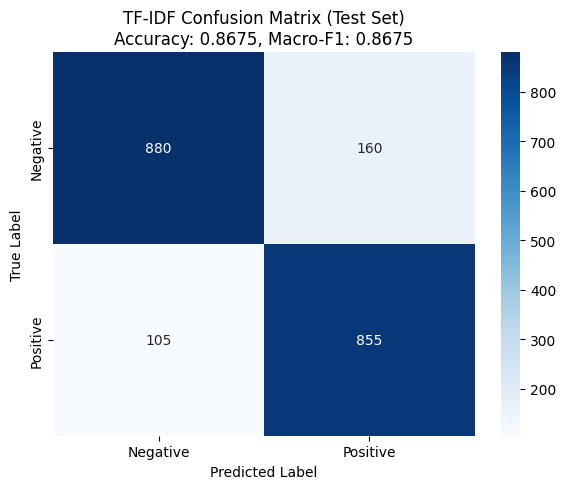


Confusion Matrix Breakdown:
  True Negatives:  880 (correctly predicted negative)
  False Positives: 160 (negative predicted as positive)
  False Negatives: 105 (positive predicted as negative)
  True Positives:  855 (correctly predicted positive)


In [14]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar=True)
plt.title(f'TF-IDF Confusion Matrix (Test Set)\nAccuracy: {test_acc:.4f}, Macro-F1: {test_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Kaydet (raporda kullanacağız)
os.makedirs('q1_classification/results', exist_ok=True)
plt.savefig('q1_classification/results/tfidf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives:  {cm[0,0]} (correctly predicted negative)")
print(f"  False Positives: {cm[0,1]} (negative predicted as positive)")
print(f"  False Negatives: {cm[1,0]} (positive predicted as negative)")
print(f"  True Positives:  {cm[1,1]} (correctly predicted positive)")

In [15]:
# Yanlış tahminleri bul
test_subset_with_preds = test_subset.copy()
test_subset_with_preds['tfidf_pred'] = test_preds
test_subset_with_preds['tfidf_correct'] = (test_preds == test_labels)
test_subset_with_preds['tfidf_pos_prob'] = test_probs[:, 1]  # Pozitif sınıf olasılığı

# Yanlışları filtrele
misclassified = test_subset_with_preds[~test_subset_with_preds['tfidf_correct']].copy()

print(f"Total misclassified: {len(misclassified)} / {len(test_subset)} "
      f"({len(misclassified)/len(test_subset)*100:.1f}%)")
print(f"\nFalse Positives (negative review predicted as positive): "
      f"{((test_subset_with_preds['label']==0) & (test_subset_with_preds['tfidf_pred']==1)).sum()}")
print(f"False Negatives (positive review predicted as negative): "
      f"{((test_subset_with_preds['label']==1) & (test_subset_with_preds['tfidf_pred']==0)).sum()}")

# Tahminli test setini kaydet — diğer modellerle karşılaştırırken kullanacağız
test_subset_with_preds.to_csv('q1_classification/results/test_predictions_tfidf.csv', index=False)
print("\n✓ Test predictions saved")

# Birkaç yanlış örneği göster
print("\n" + "=" * 70)
print("SAMPLE MISCLASSIFIED EXAMPLES")
print("=" * 70)
for i, row in misclassified.head(3).iterrows():
    label_str = 'Positive' if row['label'] == 1 else 'Negative'
    pred_str = 'Positive' if row['tfidf_pred'] == 1 else 'Negative'
    print(f"\nTrue: {label_str} | Predicted: {pred_str} (prob_pos={row['tfidf_pos_prob']:.3f})")
    print(f"Text: {row['text'][:300]}...")

Total misclassified: 265 / 2000 (13.2%)

False Positives (negative review predicted as positive): 160
False Negatives (positive review predicted as negative): 105

✓ Test predictions saved

SAMPLE MISCLASSIFIED EXAMPLES

True: Negative | Predicted: Positive (prob_pos=0.577)
Text: I've read through a lot of the comments here about how this movie sticks to the book.. I don't think any of them have actually read it. Edgar Rice wrote about a dangerous African Jungle and Apes were killers and hunters. We know differently now and this movie portrays Apes in a more modern view. I'v...

True: Positive | Predicted: Negative (prob_pos=0.333)
Text: This was very funny, even if it fell apart a little at the end. Does not go overboard with homage after to Hitchcock - Owen (Danny DeVito) was lucky he had "Strangers on A Train" playing at the local cinema, so the movie flat out tells you that that was the inspiration. <br /><br />DeVito is very fu...

True: Positive | Predicted: Negative (prob_pos=0.

In [16]:
# Tüm sonuçları yapılandırılmış olarak kaydet
results = {
    'model': 'TF-IDF + Logistic Regression',
    'best_config': best_config['config'],
    'best_config_details': {
        'lowercase': True,
        'stop_words': 'english',
        'ngram_range': [1, 2],
        'max_features': 20000,
        'sublinear_tf': True,
        'classifier': 'LogisticRegression(C=1.0, solver=liblinear)',
    },
    'subset_sizes': {
        'train': len(train_subset),
        'val': len(val_subset),
        'test': len(test_subset)
    },
    'random_seed': SEED,
    'ablation_results': ablation_df.to_dict(orient='records'),
    'test_metrics': {
        'accuracy': float(test_acc),
        'macro_f1': float(test_f1),
        'confusion_matrix': cm.tolist()
    }
}

with open('q1_classification/results/tfidf_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved to q1_classification/results/tfidf_results.json")
!cat q1_classification/results/tfidf_results.json

✓ Results saved to q1_classification/results/tfidf_results.json
{
  "model": "TF-IDF + Logistic Regression",
  "best_config": "4. Bigrams + Stopword removal",
  "best_config_details": {
    "lowercase": true,
    "stop_words": "english",
    "ngram_range": [
      1,
      2
    ],
    "max_features": 20000,
    "sublinear_tf": true,
    "classifier": "LogisticRegression(C=1.0, solver=liblinear)"
  },
  "subset_sizes": {
    "train": 5000,
    "val": 1000,
    "test": 2000
  },
  "random_seed": 42,
  "ablation_results": [
    {
      "Configuration": "1. Baseline (unigram, lowercase)",
      "Val Accuracy": 0.857,
      "Val Macro-F1": 0.8569678177589958,
      "Time (s)": 5.932892560958862
    },
    {
      "Configuration": "2. + Stopword removal",
      "Val Accuracy": 0.856,
      "Val Macro-F1": 0.8558523928502787,
      "Time (s)": 3.174048900604248
    },
    {
      "Configuration": "3. + Bigrams (uni+bi)",
      "Val Accuracy": 0.864,
      "Val Macro-F1": 0.8639733387743997,
